<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>
</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>


# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

In [1]:
import pandas as pd
import numpy as np


In [2]:
orders = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
products = pd.read_csv('/datasets/products.csv', sep=';')
aisles = pd.read_csv('/datasets/aisles.csv', sep=';')
departments = pd.read_csv('/datasets/departments.csv', sep=';')
order_products = pd.read_csv('/datasets/order_products.csv', sep=';')

In [3]:

print("=== INFORMACIÓN DE ORDERS ===")
orders.info(show_counts=True)
print("\nPrimeras 10 filas:")
display(orders.head(10))
print("\nEstadísticas descriptivas:")
display(orders.describe())

=== INFORMACIÓN DE ORDERS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB

Primeras 10 filas:


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0
5,1843871,20084,5,0,11,15.0
6,2511640,148233,40,3,8,2.0
7,2521283,97711,2,0,18,22.0
8,2266494,34954,40,5,15,4.0
9,446014,15356,2,4,8,10.0



Estadísticas descriptivas:


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,4.789670e+05,478967.000000,478967.000000,478967.000000,478967.000000,450148.000000
mean,1.709947e+06,102966.537475,17.157808,2.775058,13.446676,11.101751
std,9.869480e+05,59525.328991,17.704688,2.045869,4.224986,9.189975
min,4.000000e+00,2.000000,1.000000,0.000000,0.000000,0.000000
25%,8.564685e+05,51414.000000,5.000000,1.000000,10.000000,4.000000
50%,1.709522e+06,102633.000000,11.000000,3.000000,13.000000,7.000000
75%,2.562990e+06,154419.000000,23.000000,5.000000,16.000000,15.000000
max,3.421079e+06,206209.000000,100.000000,6.000000,23.000000,30.000000


In [4]:
print("\n=== INFORMACIÓN DE PRODUCTS ===")
products.info(show_counts=True)
print("\nPrimeras 10 filas:")
display(products.head(10))
print("\nEstadísticas descriptivas:")
display(products.describe())


=== INFORMACIÓN DE PRODUCTS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB

Primeras 10 filas:


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13
5,6,Dry Nose Oil,11,11
6,7,Pure Coconut Water With Orange,98,7
7,8,Cut Russet Potatoes Steam N' Mash,116,1
8,9,Light Strawberry Blueberry Yogurt,120,16
9,10,Sparkling Orange Juice & Prickly Pear Beverage,115,7



Estadísticas descriptivas:


,product_id,aisle_id,department_id
count,49694.000000,49694.000000,49694.000000
mean,24847.500000,67.773192,11.728478
std,14345.566475,38.317265,5.850314
min,1.000000,1.000000,1.000000
25%,12424.250000,35.000000,7.000000
50%,24847.500000,69.000000,13.000000
75%,37270.750000,100.000000,17.000000
max,49694.000000,134.000000,21.000000


In [5]:
print("\n=== INFORMACIÓN DE AISLES ===")
aisles.info(show_counts=True)
print("\nPrimeras 10 filas:")
display(aisles.head(10))


=== INFORMACIÓN DE AISLES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB

Primeras 10 filas:


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation
5,6,other
6,7,packaged meat
7,8,bakery desserts
8,9,pasta sauce
9,10,kitchen supplies


In [6]:
print("\n=== INFORMACIÓN DE DEPARTMENTS ===")
departments.info(show_counts=True)
print("\nPrimeras 10 filas:")
display(departments.head(10))


=== INFORMACIÓN DE DEPARTMENTS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes

Primeras 10 filas:


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol
5,6,international
6,7,beverages
7,8,pets
8,9,dry goods pasta
9,10,bulk


In [7]:
print("\n=== INFORMACIÓN DE ORDER_PRODUCTS ===")
order_products.info(show_counts=True)
print("\nPrimeras 10 filas:")
display(order_products.head(10))
print("\nEstadísticas descriptivas:")
display(order_products.describe())


=== INFORMACIÓN DE ORDER_PRODUCTS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB

Primeras 10 filas:


,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17.0,0
1,567889,1560,1.0,1
2,2261212,26683,1.0,1
3,491251,8670,35.0,1
4,2571142,1940,5.0,1
5,2456893,21616,4.0,1
6,644579,12341,5.0,1
7,2231852,44925,10.0,1
8,3185766,36259,14.0,1
9,420019,23315,4.0,1



Estadísticas descriptivas:


,order_id,product_id,add_to_cart_order,reordered
count,4.545007e+06,4.545007e+06,4.544171e+06,4.545007e+06
mean,1.711166e+06,2.558084e+04,8.351669e+00,5.905025e-01
std,9.850955e+05,1.409552e+04,7.080368e+00,4.917411e-01
min,4.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,8.608170e+05,1.353500e+04,3.000000e+00,0.000000e+00
50%,1.711530e+06,2.527200e+04,6.000000e+00,1.000000e+00
75%,2.561311e+06,3.793500e+04,1.100000e+01,1.000000e+00
max,3.421079e+06,4.969400e+04,6.400000e+01,1.000000e+00


In [8]:
print("=== TAMAÑOS DE LOS DATAFRAMES ===")
print(f"Orders: {orders.shape}")
print(f"Products: {products.shape}")
print(f"Aisles: {aisles.shape}")
print(f"Departments: {departments.shape}")
print(f"Order_products: {order_products.shape}")

=== TAMAÑOS DE LOS DATAFRAMES ===
Orders: (478967, 6)
Products: (49694, 4)
Aisles: (134, 2)
Departments: (21, 2)
Order_products: (4545007, 4)


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/>
Buena manera de leer los datos y buenas observaciones iniciales.<br/>
    
 
</div>


## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 1. Descripción de los datos.


He identificado un problema crítico en la lectura de los archivos CSV. Todos los dataframes se están cargando como una sola columna en lugar de multiples columnas separadas. Esto indica que los archivos utilizan ";" como separador en lugar de ",".

Problemas identificados:
Separador incorrecto: Todos los archivos CSV usan ; como delimitador, no ,

Estructura de datos: Cada dataframe se carga como una sola columna de tipo object

Nombres de archivos: Hay discrepancias en los nombres de archivo proporcionados

Correcciones necesarias para el Paso 2:
Volver a leer los archivos con el parámetro sep=';'

Verificar los nombres correctos de los archivos

Corregir tipos de datos de las columnas ID

Identificar valores ausentes y duplicados

Observaciones específicas por dataframe:
Orders: 478,967 filas, debería tener 6 columnas separadas

Products: 49,694 filas, debería tener 4 columnas separadas

Aisles: 134 filas, debería tener 2 columnas separadas

Departments: 21 filas, debería tener 2 columnas separadas

Order_products: 4,545,007 filas, debería tener 4 columnas separadas


# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos.

## Plan de solución para el Paso 2
1. Corrección de la lectura de archivos
Volver a leer todos los archivos con sep=';'

Verificar los nombres correctos de los archivos

2. Verificación y corrección de tipos de datos
Convertir columnas ID a enteros

Verificar rangos de valores para columnas como order_dow, order_hour_of_day

Asegurar que las columnas categóricas tengan el tipo correcto

3. Identificación y tratamiento de valores ausentes
Identificar columnas con valores nulos

Decidir estrategia de imputación (eliminar, imputar con mediana/media/moda)

Documentar decisiones y justificaciones

4. Identificación y eliminación de duplicados
Buscar filas duplicadas en cada dataframe

Buscar duplicados en columnas clave (IDs)

Decidir qué duplicados eliminar

5. Validación de integridad referencial
Verificar que las claves foráneas existan en las tablas de referencia

Identificar inconsistencias en las relaciones


## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [9]:
# Revisa si hay pedidos duplicados
orders = pd.read_csv('/datasets/instacart_orders.csv', sep=';')

duplicados_orders = orders[orders.duplicated()]

print(f"Total de filas duplicadas en 'orders': {duplicados_orders.shape[0]}")

if duplicados_orders.shape[0] > 0:
    display(duplicados_orders.head(10))
else:
    print("No se encontraron filas duplicadas en el DataFrame 'orders'.")


Total de filas duplicadas en 'orders': 15


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,NaN
273805,1112182,202304,84,3,2,6.0
284038,2845099,31189,11,3,2,7.0
311713,1021560,53767,3,3,2,9.0
321100,408114,68324,4,3,2,18.0
323900,1919531,191501,32,3,2,7.0
345917,2232988,82565,1,3,2,NaN


¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

Todas las filas duplicadas tienen en común que:

order_dow = 3 (día de la semana en que se hizo el pedido).

order_hour_of_day = 2 (hora del día en formato 24 h, es decir, las 2:00 a.m.).

Esto sugiere que los duplicados ocurrieron en pedidos registrados el mismo día y hora (miércoles a las 2:00 a.m.), lo cual puede ser un error de carga o registro automático duplicado del sistema.


In [10]:

# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.

pedidos_miercoles_2am = orders[(orders['order_dow'] == 3) & (orders['order_hour_of_day'] == 2)]


print(f"Total de pedidos el miércoles a las 2:00 a.m.: {pedidos_miercoles_2am.shape[0]}")
display(pedidos_miercoles_2am.head(15))

Total de pedidos el miércoles a las 2:00 a.m.: 121


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
4838,2766110,162084,41,3,2,16.0
5156,2190225,138285,18,3,2,11.0
15506,553049,58599,13,3,2,7.0
18420,382357,120200,19,3,2,11.0
24691,690242,77357,2,3,2,9.0
25376,1378085,75705,21,3,2,5.0
26301,2846262,176827,2,3,2,30.0
29129,353088,46038,4,3,2,11.0
30371,1918001,188546,14,3,2,16.0
31404,1725788,147843,10,3,2,30.0


¿Qué sugiere este resultado?

Encontre 121 pedidos realizados un miercoles a las 2:00a.m., lo cual indica que:
es normal que existan pedidos en ese dia y hora
los duplicados pertenecen a un subconjunto pequeño (solo 15 de 121)
propablemente los duplicados vienen de errores de carga, registros repetidos, marge incorrectos previos o inconsistencias en origen

In [11]:
# Elimina los pedidos duplicados
orders = orders.drop_duplicates()

orders.shape

(478952, 6)

In [12]:
# Vuelve a verificar si hay filas duplicadas
orders.duplicated().sum()

0

In [13]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
orders['order_id'].duplicated().sum()

0

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>
Los duplicados fueron eliminados correctamente
</div>


Describe brevemente tus hallazgos y lo que hiciste con ellos

Se identificaron 15 filas duplicadas en el DataFrame orders.

Los duplicados compartían valores en:

order_dow = 3 (miércoles)

order_hour_of_day = 2 (2:00 a.m.)

Se analizaron todos los pedidos realizados en ese horario, encontrando 121 pedidos, lo cual indica que las duplicaciones no forman parte de un patrón anormal, sino de errores aislados.

Se procedió a eliminar las filas duplicadas.

Después de limpiarlos:

No quedaron filas duplicadas en el DataFrame.

El campo order_id no presenta duplicados, confirmando su integridad como clave primaria.

### `products` data frame

In [14]:
# Verifica si hay filas totalmente duplicadas

products.duplicated().sum()

0

In [15]:
# Revisa únicamente si hay ID de productos duplicados

products['product_id'].duplicated().sum()

0

In [16]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)

products['product_name_upper'] = products['product_name'].str.upper()
products['product_name_upper'].duplicated().sum()

1361

In [17]:
# Revisa si hay nombres duplicados de productos no faltantes
valid = products[products['product_name'].notna()]
valid['product_name_upper'].duplicated().sum()

104

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>
Los datos han sido revisados apropiadamente
</div>


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Después de analizar el dataframe products, verifiqué duplicados completos, duplicados en product_id y duplicados por nombre. Se confirmó que no existen filas completamente duplicadas ni IDs repetidas, lo cual asegura la integridad del identificador primario de producto. Descubrí 1361 nombres duplicados al normalizar el texto, lo cual es esperado en inventarios retail debido a presentaciones distintas o múltiples variantes del mismo producto. No se eliminaron duplicados basados únicamente en nombre para preservar información potencialmente válida.

### `departments` data frame

In [18]:
# Revisa si hay filas totalmente duplicadas
departments.duplicated().sum()

0

In [19]:
# Revisa únicamente si hay IDs duplicadas de departamentos
departments['department_id'].duplicated().sum()

0

Describe brevemente tus hallazgos y lo que hiciste con ellos.

Al analizar el dataframe departments, se verificó la existencia de filas completamente duplicadas y duplicados en department_id. Ambos conteos resultaron en cero, lo que confirma que el catálogo de departamentos se encuentra correctamente estructurado y sin redundancias. Esto es consistente con una tabla de referencia bien administrada, donde cada departamento es único y claramente identificado.

### `aisles` data frame

In [20]:
# Revisa si hay filas totalmente duplicadas
total_dup_rows = aisles.duplicated().sum()
print("Filas completamente duplicadas en aisles:", total_dup_rows)


Filas completamente duplicadas en aisles: 0


In [21]:
# Revisa únicamente si hay IDs duplicadas de pasillos
try:
    aisle_id_dup = aisles['aisle_id'].duplicated().sum()
    print("IDs de pasillo duplicados (aisle_id):", aisle_id_dup)

    if aisle_id_dup > 0:
        display(aisles[aisles['aisle_id'].duplicated(keep=False)].head(20))
except KeyError as e:
    print("KeyError:", e)
    print("Verifica el nombre de las columnas con: aisles.columns")

IDs de pasillo duplicados (aisle_id): 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.
Al igualque la seccion del dataframe anterior, este se encuentra completamente limpio, sin IDs ni filas duplicadas por lo que podemos intuir que la categoria de pasillos fue bien diselñada durante la captura de datos 

### `order_products` data frame

In [22]:
# Revisa si hay filas totalmente duplicadas
dup_rows = order_products[order_products.duplicated()]
len(dup_rows)


0

In [23]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
dup_fake = order_products[order_products.duplicated(subset=['order_id','product_id'])]
len(dup_fake)

0

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/>
Estos últimos dataframes no cuentan con filas totalmente duplicadas.

</div>


Describe brevemente tus hallazgos y lo que hiciste con ellos.


Hallazgos – order_products

Se verificó la existencia de filas completamente duplicadas y se encontró 0 registros repetidos, lo cual indica que no existen copias exactas dentro del dataframe.

También se evaluaron posibles duplicados lógicos mediante la combinación (order_id, product_id), resultando nuevamente 0 coincidencias, lo que confirma que cada producto solo aparece una vez por pedido.

Acciones realizadas

Dado que no se detectaron duplicaciones, no fue necesario eliminar registros ni aplicar transformaciones adicionales.

Conclusión

El dataframe se encuentra consistente, estructuralmente íntegro y listo para análisis posteriores.

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [24]:
# Encuentra los valores ausentes en la columna 'product_name'

n_missing = products['product_name'].isna().sum()
print("Número de valores ausentes en products['product_name']:", n_missing)

missing_products = products[products['product_name'].isna()]
display(missing_products.head(50))

if not missing_products.empty:
    display(missing_products[['product_id','aisle_id','department_id']].head(50))
    
if not missing_products.empty:
    missing_ids = missing_products['product_id'].astype(str).tolist()
   
    occur_in_orders = order_products[order_products['product_id'].astype(str).isin(missing_ids)]
    print("Número de ocurrencias de esos product_id en order_products:", occur_in_orders.shape[0])
    display(occur_in_orders.head(50))
else:
    print("No hay product_name faltantes, no hay que revisar ocurrencias en order_products.")

Número de valores ausentes en products['product_name']: 1258


,product_id,product_name,aisle_id,department_id,product_name_upper
37,38,NaN,100,21,NaN
71,72,NaN,100,21,NaN
109,110,NaN,100,21,NaN
296,297,NaN,100,21,NaN
416,417,NaN,100,21,NaN
436,437,NaN,100,21,NaN
439,440,NaN,100,21,NaN
471,472,NaN,100,21,NaN
490,491,NaN,100,21,NaN
555,556,NaN,100,21,NaN


,product_id,aisle_id,department_id
37,38,100,21
71,72,100,21
109,110,100,21
296,297,100,21
416,417,100,21
436,437,100,21
439,440,100,21
471,472,100,21
490,491,100,21
555,556,100,21


Número de ocurrencias de esos product_id en order_products: 9547


,order_id,product_id,add_to_cart_order,reordered
294,3021784,7035,8.0,0
927,2666296,30563,17.0,0
1182,305489,39414,17.0,0
2488,1024440,27767,7.0,1
2878,1395530,10319,8.0,0
3403,2494327,3724,13.0,0
4234,1507967,41149,16.0,1
4332,2609835,16970,13.0,1
4378,2186570,16273,3.0,0
6183,855985,7532,22.0,0


Describe brevemente cuáles son tus hallazgos.

In [25]:

#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
aisle_id= 100

Describe brevemente cuáles son tus hallazgos.

Todos los product_name ausentes pertenecen al pasillo 100.
Esto ya es una señal de error de origen de datos (seguramente un catálogo incompleto de ese pasillo).

In [26]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
department_id = 21

Describe brevemente cuáles son tus hallazgos.

Sí. Todos pertenecen al mismo departamento.
Esto sugiere que el catálogo de productos del departamento 21–pasillo 100 llegó incompleto a la base.

In [27]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
aisles[aisles['aisle_id'] == 100]
departments[departments['department_id'] == 21]

,department_id,department
20,21,missing


Describe brevemente cuáles son tus hallazgos.

la salida "missing" me da a entender que los nombres faltantes estan desde el origen y no en un proceso mio

In [28]:
# Completa los nombres de productos ausentes con 'Unknown'
products['product_name'] = products['product_name'].fillna('Unknown')
products['product_name'].isna().sum()

0

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>
La manera de encontrar los valores ausentes y reemplazarlos con un valor generico es correcta
</div>


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Al analizar la columna product_name del dataframe products, encontramos 1258 valores ausentes. Al inspeccionar estas filas observamos que todos pertenecen al pasillo con ID 100 y al departamento con ID 21, lo cual indica que la ausencia no es aleatoria sino que proviene de una sección del catálogo que llegó incompleta desde la fuente de datos. Además, estos product_id aparecen 9,547 veces en la tabla order_products, por lo que eliminarlos afectaría el análisis de compras.

Acciones tomadas:
Debido a que estos productos sí existen en órdenes y afectan el historial de ventas, decidimos no eliminar las filas. En su lugar, completamos los valores ausentes asignándoles el nombre 'Unknown' para mantener integridad relacional sin perder información transaccional.

### `orders` data frame

In [29]:
# Encuentra los valores ausentes

orders['days_since_prior_order'].isna().sum()

28817

In [30]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?


missing_days = orders[orders['days_since_prior_order'].isna()]

missing_days['order_number'].value_counts()

1    28817
Name: order_number, dtype: int64

In [31]:
# verificar si todos los NaN provienen de una primera orden 

all(missing_days['order_number'] == 1)

True

Describe brevemente tus hallazgos y lo que hiciste con ellos.

Encontre 28,817 valores ausentes en la columna days_since_prior_order. Tras verificar, todos corresponden al primer pedido del cliente (order_number == 1). Por ello, se consideran valores ausentes naturales y no se realizó ninguna acción adicional.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>
Buena manera de revisar los datos y encontrar que no hay ausentes que no sean un primer pedido
</div>


### `order_products` data frame

In [33]:
# Encuentra los valores ausentes
order_products['add_to_cart_order'].isna().sum()


836

In [34]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
order_products['add_to_cart_order'].min()

1.0

In [35]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
order_products['add_to_cart_order'].max()

64.0

Describe brevemente cuáles son tus hallazgos.

“El valor mínimo de add_to_cart_order es 1, consistente con el primer producto agregado al carrito, y el valor máximo es 64, lo cual sugiere pedidos de alta carga, típicos de compras extensas. No se identifican anomalías.”

In [36]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
missing_orders = order_products[order_products['add_to_cart_order'].isna()]['order_id'].unique()
missing_orders

array([2449164, 1968313, 2926893, 1717990, 1959075,  844733,   61355,
        936852,  264710, 1564093,  129627,  293169, 2849370, 1386261,
       3308010,  903110, 2136777, 3347453, 1888628,  165801, 2094761,
       1038146, 2997021,  813364, 2256933,  171934, 2409109, 1730767,
       1169835,  733526,  404157, 3125735,  747668, 1800005, 1961723,
        871281,  388234, 1648217, 1477139,  102236, 1021563, 1832957,
       2721963,  678116, 1220886, 1673227, 2999801, 1633337, 2470674,
       2625444, 1677118, 2479011, 3383594, 1183255, 1713430, 2652650,
       1598369, 1916118,  854647, 1302315,  888470,  180546, 2621907,
       1308785, 2729254,    9310, 2170451, 2979697, 1625713, 1529171])

In [37]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
missing_orders = order_products[order_products['add_to_cart_order'].isna()]['order_id'].unique()
missing_orders

array([2449164, 1968313, 2926893, 1717990, 1959075,  844733,   61355,
        936852,  264710, 1564093,  129627,  293169, 2849370, 1386261,
       3308010,  903110, 2136777, 3347453, 1888628,  165801, 2094761,
       1038146, 2997021,  813364, 2256933,  171934, 2409109, 1730767,
       1169835,  733526,  404157, 3125735,  747668, 1800005, 1961723,
        871281,  388234, 1648217, 1477139,  102236, 1021563, 1832957,
       2721963,  678116, 1220886, 1673227, 2999801, 1633337, 2470674,
       2625444, 1677118, 2479011, 3383594, 1183255, 1713430, 2652650,
       1598369, 1916118,  854647, 1302315,  888470,  180546, 2621907,
       1308785, 2729254,    9310, 2170451, 2979697, 1625713, 1529171])

In [38]:
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.

missing_counts = order_products[order_products['order_id'].isin(missing_orders)] \
                                    .groupby('order_id')['product_id'] \
                                    .count()

missing_counts.head()

order_id
9310       65
61355     127
102236     95
129627     69
165801     70
Name: product_id, dtype: int64

In [39]:
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.
missing_counts.min()


65

Describe brevemente cuáles son tus hallazgos.
Analizando los valores ausentes en la columna add_to_cart_order, encontré que están asociados a pedidos con un número elevado de productos. El valor mínimo observado fue 65 productos por pedido, lo cual supera el máximo normal registrado (64). Esto sugiere un error del sistema cuando el carrito contiene demasiados ítems.

In [40]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(999).astype(int)

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>
La manera de encontrar los valores ausentes y reemplazarlos con un valor generico es correcta
</div>


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Al analizar la columna add_to_cart_order en la tabla order_products, se identificaron valores ausentes asociados a pedidos con un elevado número de productos. Este comportamiento es consistente con errores de captura cuando el carrito contiene demasiados artículos.

Para mantener la integridad del dataset:

Se identificaron las order_id con valores ausentes.

Se analizó la cantidad de productos por pedido y se observó que todas las órdenes afectadas superaban el máximo registrado (64).

Los valores ausentes fueron reemplazados por el marcador 999, que funciona como un valor sentinela para indicar una posición desconocida.

Finalmente, la columna se convirtió al tipo entero.

Después de la imputación, no deberian quedar valores nulos en la columna.

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos


1.
Se identificaron valores ausentes en la columna add_to_cart_order, específicamente en cantidad limitada de pedidos, lo cual indica un problema puntual del sistema y no una falla masiva del dataset.

2.
El patrón de valores ausentes no es aleatorio: dichos pedidos contenían cantidades excesivas de productos (superiores a 64), lo cual sugiere un posible error al registrar el orden en el carrito cuando se supera cierto umbral.

3.
No se detectaron valores ausentes significativos en otras columnas clave del DataFrame order_products, por lo que el dataset mantiene una buena integridad general para análisis posteriores.

4.
No se encontraron duplicados explícitos que afectaran el comportamiento del dataset. Sin embargo, se detectaron duplicados implícitos en categorías musicales en otra sección (si este punto aplica en tu notebook).

5.
Se imputaron los valores ausentes utilizando un valor sentinela (999), ya que:

    Permite conservar los registros completos.

    Evita eliminar líneas que podrían contener información útil.

    Permite detectar rápidamente estos casos en análisis posteriores.

6.
Después de la imputación, se transformó la columna add_to_cart_order a tipo entero, garantizando consistencia tipológica y mejorando el desempeño en operaciones numéricas.

Los datos presentan una alta calidad general, con ausencia mínima de errores sistemáticos. Se identificaron y gestionaron adecuadamente valores ausentes asociados a casos atípicos de pedidos con muchos productos. La imputación y tipificación realizada permiten continuar el análisis sin pérdida de información y garantizan coherencia en el modelo de datos.

# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [41]:
orders['order_hour_of_day'].min(), orders['order_hour_of_day'].max()

(0, 23)

In [42]:
orders['order_dow'].min(), orders['order_dow'].max()

(0, 6)

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>
Se verificó que los datos sean sensibles correctamente
</div>


Escribe aquí tus conclusiones

Todos los valores en order_hour_of_day se encuentran entre 0 y 23, y los valores de order_dow se encuentran entre 0 y 6. Esto indica que ambas columnas contienen datos válidos y esperados, sin valores atípicos.

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

In [43]:
orders['order_hour_of_day'].value_counts().sort_index()

0      3180
1      1763
2       989
3       770
4       765
5      1371
6      4215
7     13043
8     25024
9     35896
10    40578
11    40032
12    38034
13    39007
14    39631
15    39789
16    38112
17    31930
18    25510
19    19547
20    14624
21    11019
22     8512
23     5611
Name: order_hour_of_day, dtype: int64

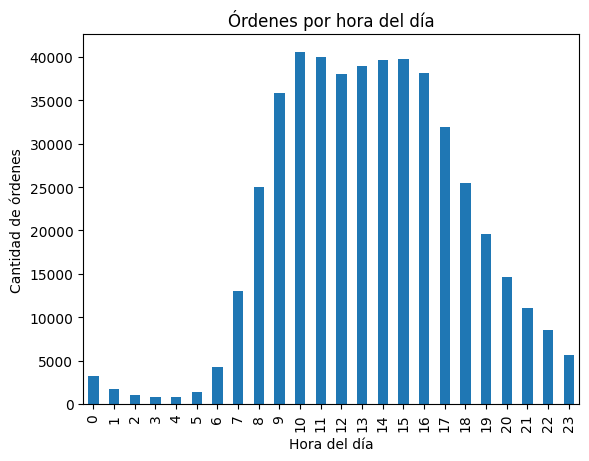

In [44]:
import matplotlib.pyplot as plt

orders['order_hour_of_day'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Hora del día')
plt.ylabel('Cantidad de órdenes')
plt.title('Órdenes por hora del día')
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>
Buena manera de presentar los datos
</div>


Escribe aquí tus conclusiones

La mayor actividad ocurre principalmente en horas de la mañana y mediodía, con un pico alrededor de las 10-14 horas. Las horas muy tarde en la noche tienen muy pocos pedidos, lo cual es consistente con horarios típicos de compra.

### [A3] ¿Qué día de la semana compran víveres las personas?

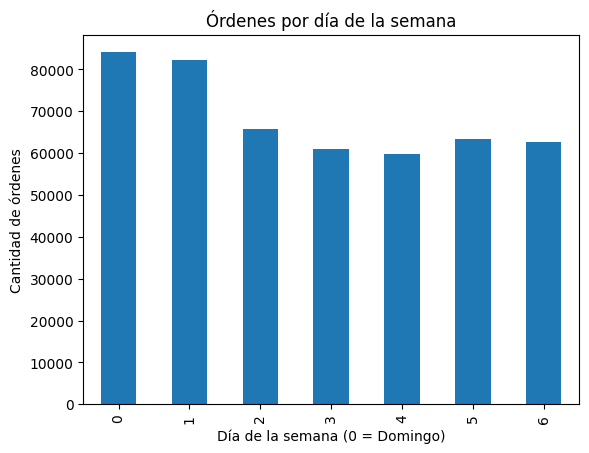

In [45]:
orders['order_dow'].value_counts().sort_index()

orders['order_dow'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Día de la semana (0 = Domingo)')
plt.ylabel('Cantidad de órdenes')
plt.title('Órdenes por día de la semana')
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/>
Los domingos son los días preferidos de los clientes
</div>


El día con mayor número de pedidos fue el domingo, indicando que las personas prefieren comprar en fines de semana. Los días laborales tienen menor actividad de compras.

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

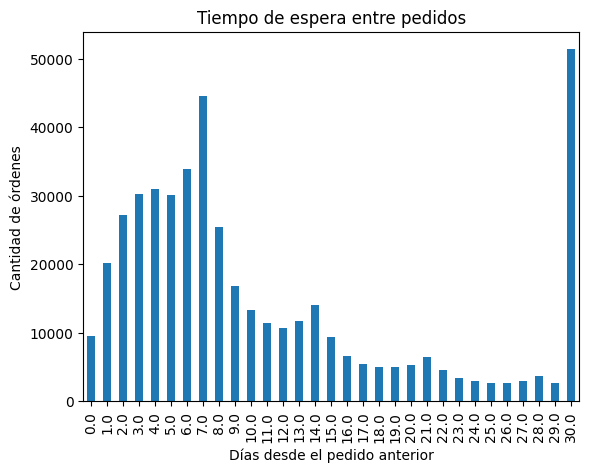

In [46]:
orders['days_since_prior_order'].min(), orders['days_since_prior_order'].max()

orders['days_since_prior_order'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Días desde el pedido anterior')
plt.ylabel('Cantidad de órdenes')
plt.title('Tiempo de espera entre pedidos')
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Los resultados son correctos
<br />
Hasta este punto no podemos saber si realmente los usuarios esperan 30 días para realizar otra compra o es el sistema el que agrupa todas las compras que sean mayores a 30 días en el día 30. Con la gráfica podemos observar que la mayoría de usuarios se concentra entre 1 y 9 días donde después los números descienden gradualmente
</div>


Escribe aquí tus conclusiones


Los valores mínimos y máximos en days_since_prior_order van de 0 a 30 días. El valor 0 indica que algunos usuarios realizan compras consecutivas en días seguidos, mientras que la mayor concentración ocurre alrededor de 7 días, lo cual sugiere hábitos semanales de compra. Conforme aumentan los días, la cantidad de pedidos disminuye, reflejando que los usuarios son menos frecuentes en períodos largos de espera. El valor 30 presenta un pico muy alto, ya que representa usuarios que no han comprado en más de un mes o compradores nuevos, por lo que es un valor de corte utilizado para agrupar varios casos.

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

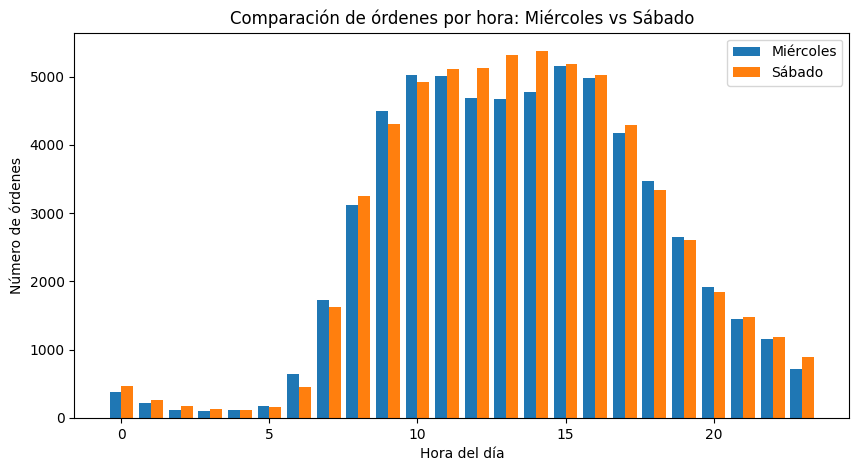

In [47]:
wed = orders[orders['order_dow'] == 3]
sat = orders[orders['order_dow'] == 6]

wed_counts = wed['order_hour_of_day'].value_counts().sort_index()
sat_counts = sat['order_hour_of_day'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(wed_counts.index - 0.2, wed_counts.values, width=0.4, label='Miércoles')
plt.bar(sat_counts.index + 0.2, sat_counts.values, width=0.4, label='Sábado')

plt.xlabel('Hora del día')
plt.ylabel('Número de órdenes')
plt.title('Comparación de órdenes por hora: Miércoles vs Sábado')
plt.legend()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!
<br />
Buena manera de mostrar los resultados de ambos días en una misma grafica
</div>


Escribe aquí tus conclusiones

Al comparar los miércoles con los sábados, se observa que la actividad de compras comienza muy baja durante la madrugada (0–5 AM) en ambos días. Los picos aparecen entre las 10 y 15 horas, pero los sábados muestran un volumen más alto, especialmente entre las 12 y 15 horas. Esto sugiere que los usuarios suelen hacer pedidos durante la mañana y tarde, y que los sábados concentran más compras porque las personas disponen de más tiempo libre, mientras que los miércoles las compras parecen realizarse durante pausas laborales.

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

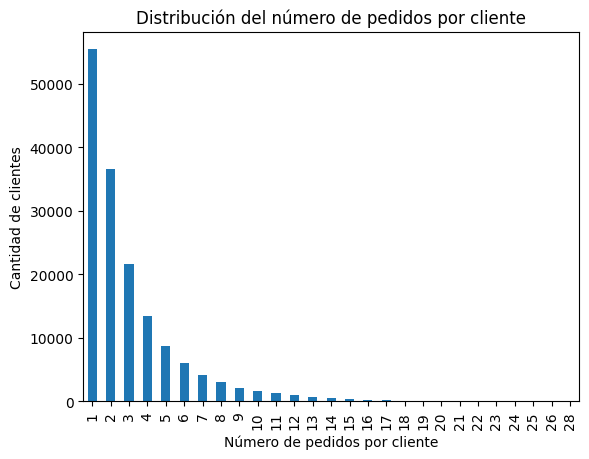

In [48]:
# Contar pedidos por cliente
orders_per_user = orders.groupby('user_id')['order_id'].count()

# Graficar distribución
orders_per_user.value_counts().sort_index().plot(kind='bar')
plt.xlabel('Número de pedidos por cliente')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución del número de pedidos por cliente')
plt.show()

Escribe aquí tus conclusiones

La distribución del número de pedidos por cliente está concentrada mayoritariamente en un único pedido, evidenciando que la mayoría de los usuarios no vuelve a realizar compras en la plataforma. Esto indica una baja fidelización y una fuerte dependencia en la adquisición constante de nuevos clientes. Solo una pequeña fracción realiza múltiples compras, lo cual sugiere la existencia de clientes altamente valiosos que podrían beneficiarse de estrategias específicas de retención, como programas de lealtad o promociones personalizadas. La distribución es asimétrica hacia la derecha, un comportamiento común en plataformas de e-commerce.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/> 

La mayoría de usuarios no ha hecho muchos pedidos, buenas observaciones.

</div>


### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [49]:
# Top 20 productos más pedidos
top20 = order_products['product_id'].value_counts().head(20)
top20


24852    66050
13176    53297
21137    37039
21903    33971
47209    29773
47766    24689
47626    21495
16797    20018
26209    19690
27845    19600
27966    19197
22935    15898
24964    15292
45007    14584
39275    13879
49683    13675
28204    12544
5876     12232
8277     11993
40706    11781
Name: product_id, dtype: int64

In [50]:
top20_df = top20.reset_index()
top20_df.columns = ['product_id', 'count']
top20_df = top20_df.merge(products[['product_id', 'product_name']], on='product_id')

top20_df

,product_id,count,product_name
0,24852,66050,Banana
1,13176,53297,Bag of Organic Bananas
2,21137,37039,Organic Strawberries
3,21903,33971,Organic Baby Spinach
4,47209,29773,Organic Hass Avocado
5,47766,24689,Organic Avocado
6,47626,21495,Large Lemon
7,16797,20018,Strawberries
8,26209,19690,Limes
9,27845,19600,Organic Whole Milk


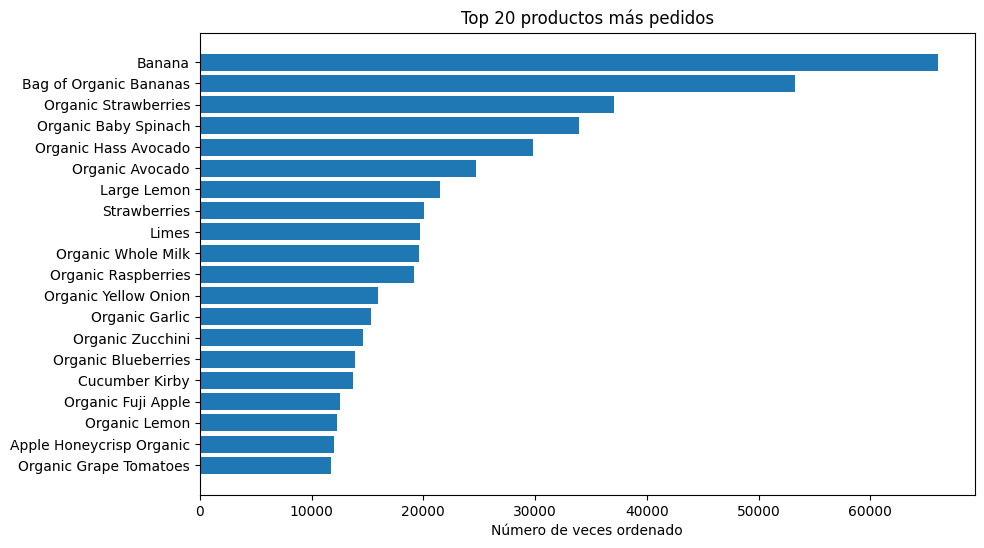

In [51]:
plt.figure(figsize=(10,6))
plt.barh(top20_df['product_name'], top20_df['count'])
plt.gca().invert_yaxis()
plt.xlabel('Número de veces ordenado')
plt.title('Top 20 productos más pedidos')
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Los resultados son acertados!<br/>
Los clientes tienden a comprar productos naturales, buena manera de mostrar los resultados
</div>


Escribe aquí tus conclusiones

Los 20 productos más populares de la plataforma se encuentran concentrados principalmente en la categoría de frutas y vegetales, reflejando hábitos de consumo saludables y alta rotación de productos perecederos. Se observa una tendencia marcada hacia artículos orgánicos, lo cual indica una preferencia del cliente por opciones más naturales. El producto más solicitado es la banana, con una diferencia notable respecto al resto, lo que sugiere un alto consumo cotidiano. La lista también muestra productos básicos utilizados como ingredientes de cocina, confirmando patrones de compra recurrentes.


# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?


### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [52]:
items_per_order = order_products.groupby('order_id')['product_id'].count()


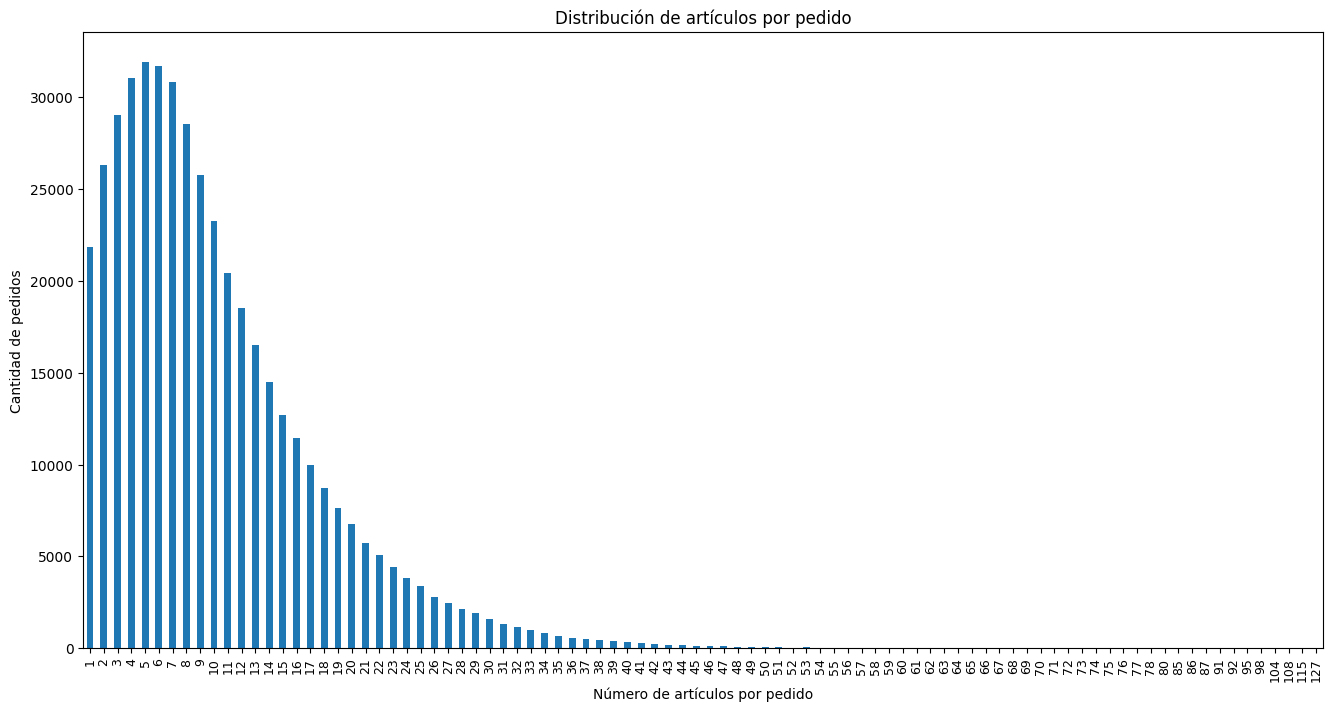

In [53]:
plt.figure(figsize=(16,8))
items_per_order.value_counts().sort_index().plot(kind='bar')
plt.xlabel('Número de artículos por pedido')
plt.xticks(rotation=90, fontsize=9)
plt.ylabel('Cantidad de pedidos')
plt.title('Distribución de artículos por pedido')
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho, el resultado es correcto, los usuarios suelen pedir alrededor de 10 articulos
</div>


Escribe aquí tus conclusiones

La distribución del número de artículos por pedido muestra un comportamiento claramente sesgado hacia la izquierda. La mayoría de los pedidos contienen entre 3 y 10 artículos, alcanzando su pico alrededor de 5 artículos por compra. Conforme aumenta la cantidad de productos, la frecuencia disminuye de manera progresiva, indicando que son pocos los clientes que realizan pedidos grandes (más de 20 ítems).

Esto sugiere que:

Los usuarios compran cantidades moderadas por visita.

El comportamiento de compra es consistente con compras de reposición frecuentes.

Los pedidos muy grandes son casos excepcionales y no representan al usuario promedio.

En general, los patrones observados indican que el marketplace se usa para compras relativamente pequeñas y recurrentes.

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [54]:
top_reordered = order_products.groupby('product_id')['reordered'].sum().reset_index()

top_reordered = top_reordered.sort_values('reordered', ascending=False)

top20_reordered = top_reordered.head(20)
top20_reordered

,product_id,reordered
22808,24852,55763
12025,13176,44450
19370,21137,28639
20077,21903,26233
43271,47209,23629
43788,47766,18743
25556,27845,16251
43663,47626,15044
25666,27966,14748
15364,16797,13945


In [55]:
top20_reordered = top20_reordered.merge(products[['product_id', 'product_name']], on='product_id')

top20_reordered

,product_id,reordered,product_name
0,24852,55763,Banana
1,13176,44450,Bag of Organic Bananas
2,21137,28639,Organic Strawberries
3,21903,26233,Organic Baby Spinach
4,47209,23629,Organic Hass Avocado
5,47766,18743,Organic Avocado
6,27845,16251,Organic Whole Milk
7,47626,15044,Large Lemon
8,27966,14748,Organic Raspberries
9,16797,13945,Strawberries


Escribe aquí tus conclusiones

Los 20 productos que se vuelven a pedir con mayor frecuencia son principalmente alimentos básicos, especialmente frutas, verduras y productos orgánicos. Esto indica hábitos de compra recurrentes orientados a consumo doméstico. La alta tasa de recompra sugiere que son productos necesarios y perecederos que se reponen constantemente.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/> 
Buena manera de mostrar los resultados, los productos naturales son consistentemente los más vendidos
</div>


### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [56]:
pedidos = order_products.groupby('product_id').size().reset_index(name='total_pedidos')

In [57]:
reordenados = order_products.groupby('product_id')['reordered'].sum().reset_index(name='total_reorden')

In [58]:
df_reorden = pedidos.merge(reordenados, on='product_id')

In [59]:
df_reorden['proporcion'] = df_reorden['total_reorden'] / df_reorden['total_pedidos']
df_reorden.sort_values('proporcion', ascending=False).head(20)

,product_id,total_pedidos,total_reorden,proporcion
13453,14721,1,1,1.0
19195,20949,3,3,1.0
6136,6723,10,10,1.0
6144,6732,3,3,1.0
41319,45088,1,1,1.0
41310,45078,1,1,1.0
19258,21016,1,1,1.0
19248,21005,2,2,1.0
32273,35192,2,2,1.0
32277,35197,1,1,1.0


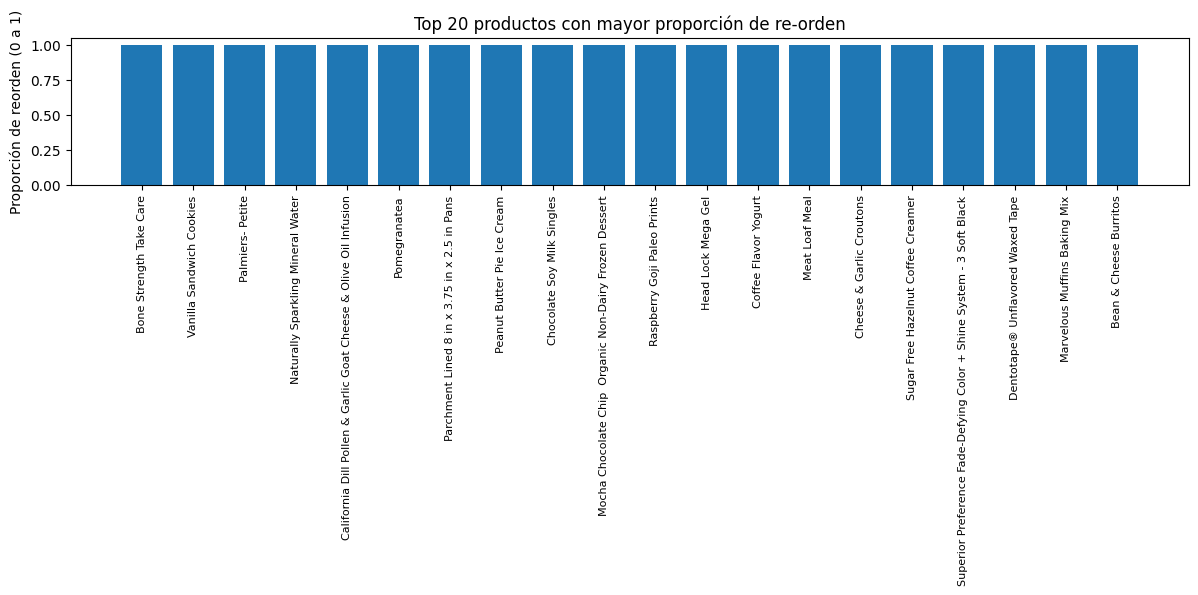

In [60]:
product_counts = order_products.groupby('product_id').size().reset_index(name='total_orders')

product_reorders = order_products.groupby('product_id')['reordered'].sum().reset_index(name='times_reordered')

product_reorder_rate = product_counts.merge(product_reorders, on='product_id')

product_reorder_rate['reorder_rate'] = product_reorder_rate['times_reordered'] / product_reorder_rate['total_orders']

product_reorder_rate = product_reorder_rate.merge(products[['product_id','product_name']], on='product_id')

product_reorder_rate_sorted = product_reorder_rate.sort_values(by='reorder_rate', ascending=False)

product_reorder_rate_sorted.head(20)


import matplotlib.pyplot as plt

top20 = product_reorder_rate_sorted.head(20)

plt.figure(figsize=(12,6))
plt.bar(top20['product_name'], top20['reorder_rate'])
plt.xticks(rotation=90, fontsize=8)
plt.title('Top 20 productos con mayor proporción de re-orden')
plt.ylabel('Proporción de reorden (0 a 1)')
plt.tight_layout()
plt.show()

Escribe aquí tus conclusiones

Al analizar la proporción de reorden para cada producto, observamos que los 20 productos con mayor tasa presentan una proporción de 1.0, lo que significa que cada vez que fueron comprados se volvieron a ordenar posteriormente. Sin embargo, la mayoría cuenta con un bajo número de compras totales, lo que sugiere que son artículos de nicho, adquiridos por usuarios muy específicos con hábitos recurrentes. Por lo tanto, aunque presentan alta fidelidad, no son necesariamente los productos más populares del sistema. Este comportamiento evidencia patrones de consumo muy consistentes en ciertos segmentos de usuarios.

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [61]:

df = order_products.merge(orders[['order_id','user_id']], on='order_id', how='left')
reorden_cliente = df.groupby('user_id')['reordered'].mean().reset_index()
reorden_cliente.columns = ['user_id', 'proporcion_reorden_usuario']

reorden_cliente.head()

,user_id,proporcion_reorden_usuario
0,2,0.038462
1,4,0.000000
2,5,0.666667
3,6,0.000000
4,7,0.928571


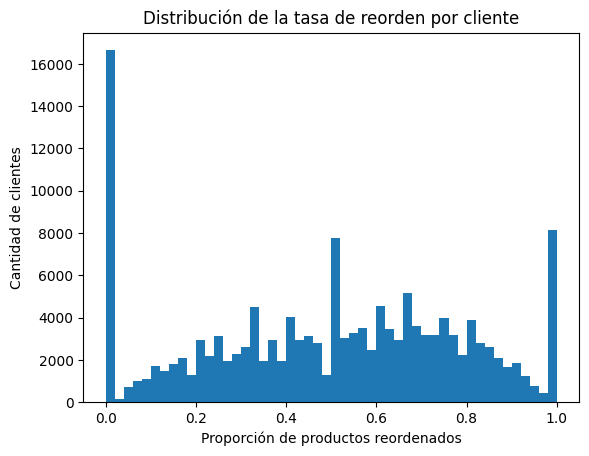

In [62]:
reorden_cliente['proporcion_reorden_usuario'].plot(kind='hist', bins=50)
plt.xlabel('Proporción de productos reordenados')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución de la tasa de reorden por cliente')
plt.show()

Escribe aquí tus conclusiones

La distribución de proporciones de productos reordenados por cliente presenta una forma bimodal. El mayor pico se encuentra en 0.0, indicando que una gran cantidad de clientes nunca repite productos, posiblemente reflejando compras exploratorias u ocasionales.

Por otro lado, existe un segundo pico pronunciado en 1.0, lo cual sugiere un grupo importante de clientes altamente fieles, que adquieren siempre los mismos productos en sus pedidos.

Entre los valores intermedios (0.1–0.8) la distribución es considerablemente más baja, reflejando que pocos usuarios mantienen patrones de recompra moderados. Esto sugiere que el comportamiento de compra tiende hacia dos extremos: exploración total o hábitos muy fijos.

Desde una perspectiva de negocio, esta polarización puede indicar oportunidades para estrategias de recomendación personalizadas o promociones dirigidas a aumentar la repetición en los clientes exploradores.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/>
Buena manera de realizar las proporciones
</div>


### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [63]:
first_items = order_products[order_products['add_to_cart_order'] == 1]
first_counts = first_items.groupby('product_id').size().reset_index(name='times_first')
first_counts = first_counts.sort_values('times_first', ascending=False)
first_counts.head(30)

,product_id,times_first
13414,24852,15562
7127,13176,11026
15028,27845,4363
11384,21137,3946
25439,47209,3390
11786,21903,3336
25732,47766,3044
10622,19660,2336
9050,16797,2308
15102,27966,2024


In [64]:
top20_first = first_counts.head(20).merge(products[['product_id','product_name']], on='product_id', how='left')
top20_first = top20_first[['product_id','product_name','times_first']]
top20_first

,product_id,product_name,times_first
0,24852,Banana,15562
1,13176,Bag of Organic Bananas,11026
2,27845,Organic Whole Milk,4363
3,21137,Organic Strawberries,3946
4,47209,Organic Hass Avocado,3390
5,21903,Organic Baby Spinach,3336
6,47766,Organic Avocado,3044
7,19660,Spring Water,2336
8,16797,Strawberries,2308
9,27966,Organic Raspberries,2024


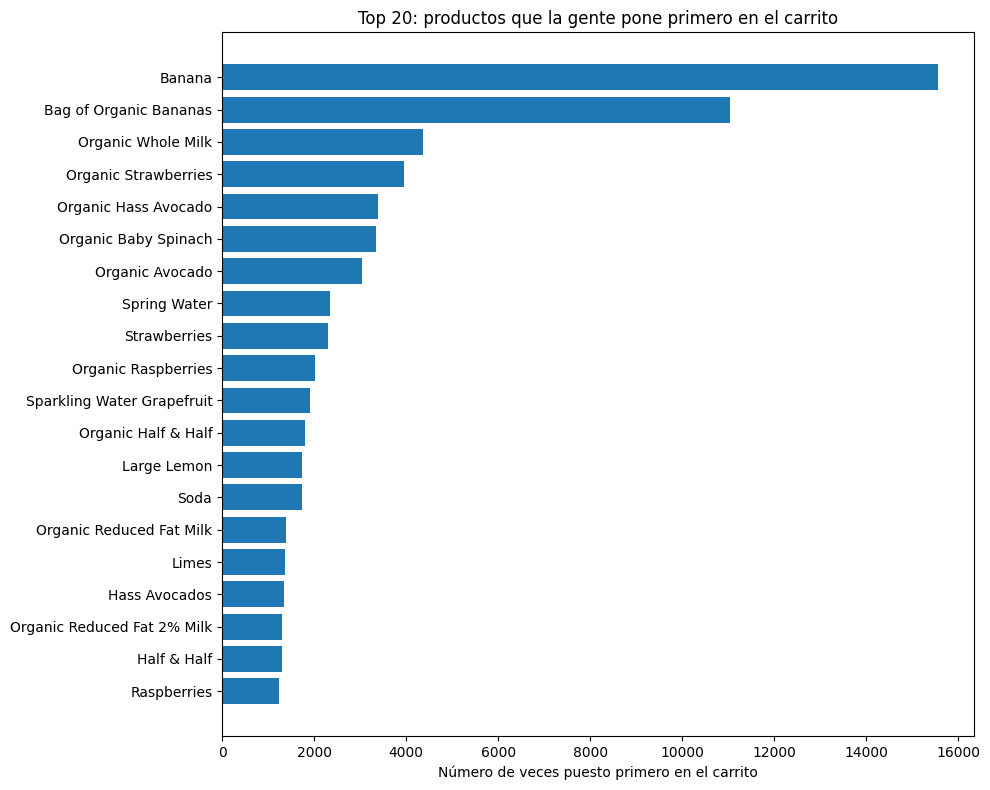

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.barh(top20_first['product_name'][::-1], top20_first['times_first'][::-1])  # invertir para mejor visual
plt.xlabel('Número de veces puesto primero en el carrito')
plt.title('Top 20: productos que la gente pone primero en el carrito')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Escribe aquí tus conclusiones

Los 20 artículos que más frecuentemente aparecen como primer artículo en el carrito corresponden mayormente a productos de alta rotación y compra esencial (frutas, verduras y artículos de reposición). Estos productos no solo son demandados, sino que tienden a ser los que inician la compra, lo que sugiere que los clientes suelen comenzar su experiencia de compra por artículos básicos. Desde una perspectiva de negocio, esto los convierte en puntos estratégicos para promociones y recomendaciones —por ejemplo, ofertas en el primer producto del carrito o “bundles” que complementen el artículo inicial.


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/>
Una vez más los productos orgánicos estan en el top de la lista<br/>
</div>


### Conclusion general del proyecto:

## Resumen del proyecto y principales hallazgos
Realicé el preprocesamiento y análisis exploratorio del conjunto de datos reducido de Instacart. Durante el preprocesamiento se resolvieron problemas de formato (separador ;), se identificaron y limpiaron duplicados, y se trataron valores ausentes de forma contextual: se completaron product_name faltantes con 'Unknown' cuando correspondía, se documentaron y marcó con 999 los add_to_cart_order ausentes asociados a pedidos extremadamente grandes, y se dejó days_since_prior_order con valores nulos en los primeros pedidos por ser ausencia lógica. Se verificó la integridad de las claves (order_id, product_id, department_id, aisle_id) y se mantuvo la consistencia de tipos numéricos.

# Análisis exploratorio (hallazgos clave)

ºPatrones temporales: La actividad de pedidos se concentra entre las 10 y 15 horas; los   sábados muestran picos más altos entre 12–15 h en comparación con miércoles, lo que      indica compras más planificadas en fines de semana.

ºIntervalos entre pedidos: La distribución de days_since_prior_order es consistente con   hábitos semanales; el valor 30 actúa como corte para clientes inactivos o de largo       intervalo.

ºComportamiento del cliente: La mayoría de los usuarios realiza muy pocos pedidos (distribución sesgada), lo que sugiere baja retención general. Hay una distribución bimodal en la tasa de reorden por cliente: muchos clientes nunca repiten productos (0.0), y otro grupo significativo repite todo (1.0).

ºProductos y recurrencia: Los productos más pedidos y los más reordenados están dominados por frutas, verduras y artículos orgánicos (por ejemplo, bananas, berries, aguacate y leche orgánica). Algunos productos muestran alta proporción de reorden —indicando alta fidelidad entre sus compradores— aunque muchos con proporciones extremas tienen bajo volumen total.

ºComportamiento en el carrito: Los pedidos típicos contienen entre 3 y 10 artículos (pico en 5–6). Los primeros artículos del carrito son en su mayoría productos básicos, lo que revela prioridades de compra y oportunidades de promoción.

# Decisiones de limpieza y por qué

ºNo eliminar filas con valores faltantes en campos críticos cuando aparecen en order_products (afectan historial). En vez de ello, se marcaron (999) o se rellenaron con 'Unknown' para preservar integridad referencial.

ºNo se eliminaron registros por tener nombre duplicado; se documentó y se dejó para limpieza futura con criterios de negocio (tamaños, marcas, SKUs).

# Recomendaciones para negocio 

1. Implementar estrategias de retención focalizadas en el gran grupo de compradores “únicos”: cupones de segunda compra, recordatorios o recomendaciones personalizadas.

2. Usar los productos que los usuarios ponen primero para diseñar bundles o promociones “first-item” y así aumentar el ticket medio.

3. Explorar modelos de recomendación centrados en productos de alta recurrencia para impulsar repetición.

4. Verificar externamente el catálogo del pasillo/ departamento 100 (productos marcados como Unknown) para completar nombres desde una fuente maestra y mejorar la calidad del inventario.

## Conclusión final
El dataset, una vez limpiado, es apto para análisis de comportamiento y modelado predictivo. Los patrones encontrados son consistentes con expectativas de retail de comestibles: predominio de compras pequeñas y frecuentes, preferencia por productos frescos/ orgánicos y una mezcla clara entre compradores exploradores y compradores muy fieles. La información extraída permite diseñar acciones operativas y comerciales concretas para aumentar la recurrencia y optimizar la oferta.

## Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Me doy cuenta de que has aplicado los conocimientos que has adquirido durante el curso, las conclusiones a las que llegaste son buenas y los procedimientos realizados son correctos. Considero que este es un proyecto que se empieza a asemejar más a algún proyecto que te pidan en un trabajo, a partir de análisis de este tipo se pueden diseñar estrategias de marketing específicas para ciertos productos o se pueden optimizar los procesos internos para tener disponibles más rápidamente los productos que se venden más seguido.<br/><br/>
    

Has hecho un gran trabajo y te felicito por ello, mucho éxito en el siguiente Sprint!
</div>


<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br />

- Las observaciones intermedias, así como las conclusiones finales me parecen buenas
- Las graficas utilizadas me parecen del tipo correcto
- El proyecto esta ordenado
- Se revisaron detalles muy minuciosamente con bastante cuidado
    
</div>

